# Optimal $N_g$ Analysis: Finite-$\Delta$ and Large-$\Delta$ Regimes

This notebook numerically solves for the optimal gate count $N_g$ from the exact stationarity condition:
$$
\ln(1-\epsilon)[\alpha e^{-f}+\beta e^{-\kappa N_g}+E_{\mathrm{gs}}]= -\alpha e^{-f}\mu_0\Delta\left[\frac{N_g(1+\lambda)-110}{N_g^2(N_g-110)^{\lambda+1}}\right]+\beta\kappa e^{-\kappa N_g}.
$$

**Key insight from the analysis:**
- For $\Delta \lesssim \Delta_{\mathrm{cross}}$: Low-noise approximation valid, curves follow noise-independent prediction
- For $\Delta \gtrsim \Delta_{\mathrm{cross}}$: Crossover to large-$\Delta$ regime, curves saturate to $\epsilon$-dependent ceilings

## 1) Parameters from Table I
Using fitted values from the paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import root_scalar, fsolve, minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# Parameters from Table I
params = {
    "epsilon": 1e-5,
    "alpha": 2.0,           # fiducial value
    "beta": 3.94,           # from Table I
    "kappa": 0.01,          # from Table I
    "E_gs": -7.711545013271975,
    "mu0": 1.09,            # from Table I (was 0.78)
    "Delta": 5e4,
    "lam": 0.63,            # from Table I (was 0.58)
    "Ng_th": 110,           # threshold from Table I (was 100)
}

print("Parameters from Table I:")
for k, v in params.items():
    print(f"  {k} = {v}")

Parameters from Table I:
  epsilon = 1e-05
  alpha = 2.0
  beta = 3.94
  kappa = 0.01
  E_gs = -7.711545013271975
  mu0 = 1.09
  Delta = 50000.0
  lam = 0.63
  Ng_th = 110


## 2) Exact Stationarity Condition
The residual is LHS - RHS of the full equation.

In [2]:
def residual_ng(Ng, p):
    """Full stationarity condition residual (Eq. exact_full in paper)."""
    eps = p["epsilon"]
    alpha = p["alpha"]
    beta = p["beta"]
    kappa = p["kappa"]
    E_gs = p["E_gs"]
    mu0 = p["mu0"]
    Delta = p["Delta"]
    lam = p["lam"]
    Ng_th = p["Ng_th"]

    if Ng <= Ng_th:
        return np.nan
    if 1 - eps <= 0:
        return np.nan

    # f(N_g) = mu0 * Delta / (N_g * (N_g - Ng_th)^lam)
    f_ng = (mu0 * Delta) / (Ng * (Ng - Ng_th) ** lam)

    lhs = np.log(1 - eps) * (alpha * np.exp(-f_ng) + beta * np.exp(-kappa * Ng) + E_gs)
    rhs = -alpha * np.exp(-f_ng) * mu0 * Delta * (
        (Ng * (1 + lam) - Ng_th) / (Ng**2 * (Ng - Ng_th) ** (lam + 1))
    ) + beta * kappa * np.exp(-kappa * Ng)

    return lhs - rhs

# Quick check
print(f"Residual at Ng=300: {residual_ng(300.0, params):.6f}")

Residual at Ng=300: -0.001773


## 3) Numerical Solver

In [3]:
def solve_ng_for_delta(delta, p):
    """
    Solve for N_g given a fixed Delta.
    Returns N_g or np.nan if no solution found.
    """
    p_delta = dict(p)
    p_delta["Delta"] = delta
    Ng_th = p["Ng_th"]

    # Search range for N_g
    ng_min = Ng_th + 10
    ng_max = min(1.0e8, delta)

    # Attempt to bracket a root
    grid = np.logspace(np.log10(ng_min), np.log10(ng_max), 300)
    res = np.array([residual_ng(x, p_delta) for x in grid])

    bracket = None
    for i in range(len(grid) - 1):
        if np.isfinite(res[i]) and np.isfinite(res[i + 1]) and res[i] * res[i + 1] < 0:
            bracket = (grid[i], grid[i + 1])
            break

    if bracket:
        sol = root_scalar(lambda x: residual_ng(x, p_delta), bracket=bracket, method="brentq")
        return sol.root if sol.converged else np.nan
    else:
        # Fallback to fsolve with an initial guess
        guess = 300.0
        sol = fsolve(lambda x: residual_ng(x, p_delta), guess, full_output=True)
        return sol[0][0] if sol[2] == 1 else np.nan

# Test
print(f"Optimal Ng at Δ=5e4: {solve_ng_for_delta(5e4, params):.1f}")

Optimal Ng at Δ=5e4: 391.5


## 4) Validity Analysis of Low-Noise Approximation

The low-noise balance requires that the entire noise-induced bias (LHS of the stationarity condition)
be negligible compared to the algorithmic terms (RHS). The validity condition reduces to:

$$\frac{\epsilon\,|E_{\mathrm{gs}}|}{\beta\kappa\, e^{-\kappa N_g}} \ll 1$$

This is $N_g$-dependent: as $\Delta$ increases and $N_g^*$ grows, the ratio eventually hits $O(1)$,
defining the $\epsilon$-dependent crossover depth $N_g^{\mathrm{cross}}(\epsilon) = \frac{1}{\kappa}\ln\left(\frac{\beta\kappa}{\epsilon|E_{\mathrm{gs}}|}\right)$.

In [4]:
def check_validity_conditions(Ng, Delta, eps, p):
    """
    Check validity of low-noise approximation at given operating point.
    Returns dict with ratios for both conditions.
    """
    kappa = p["kappa"]
    mu0 = p["mu0"]
    lam = p["lam"]
    Ng_th = p["Ng_th"]
    alpha = p["alpha"]
    E_gs = p["E_gs"]
    
    # Condition 1: RHS
    R_rhs = eps / kappa
    
    # Condition 2: LHS
    lhs_denom = (1 + lam) * mu0 * Delta / (Ng ** (2 + lam))
    R_lhs = eps / lhs_denom if lhs_denom > 0 else np.inf
    
    # f(Ng) for crossover analysis
    f_ng = mu0 * Delta / (Ng * (Ng - Ng_th) ** lam)
    
    # Crossover: alpha * exp(-f) vs epsilon * Ng * |E_gs|
    convergence_error = alpha * np.exp(-f_ng)
    noise_bias = eps * Ng * abs(E_gs)
    
    return {
        "R_rhs": R_rhs,
        "R_lhs": R_lhs,
        "f_ng": f_ng,
        "kappa_Ng": kappa * Ng,
        "convergence_error": convergence_error,
        "noise_bias": noise_bias,
        "crossover_ratio": noise_bias / convergence_error if convergence_error > 0 else np.inf
    }

# Compute crossover Delta from first principles
def compute_delta_crossover(Ng, eps, p):
    """
    Compute crossover Delta where noise bias equals convergence error.
    From: alpha * exp(-f) = epsilon * Ng * |E_gs|
    """
    alpha = p["alpha"]
    E_gs = p["E_gs"]
    mu0 = p["mu0"]
    lam = p["lam"]
    Ng_th = p["Ng_th"]
    
    # f at crossover: f = ln(alpha / (eps * Ng * |E_gs|))
    f_cross = np.log(alpha / (eps * Ng * abs(E_gs)))
    
    if f_cross <= 0:
        return np.nan
    
    # Delta_cross = f_cross * Ng * (Ng - Ng_th)^lam / mu0
    Delta_cross = f_cross * Ng * (Ng - Ng_th)**lam / mu0
    
    return Delta_cross

print("=" * 60)
print("VALIDITY ANALYSIS OF LOW-NOISE APPROXIMATION")
print("=" * 60)

# Test Condition 1 (RHS) for all simulated epsilon values
print("\n--- Condition 1: ε << κ ---")
print(f"κ = {params['kappa']}")
eps_list = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4]
for eps in eps_list:
    ratio = eps / params['kappa']
    status = "✓" if ratio < 0.1 else "marginal" if ratio < 1 else "✗"
    print(f"  ε = {eps:.0e}: ε/κ = {ratio:.1e} {status}")

# Test Condition 2 (LHS) at representative operating points
print("\n--- Condition 2: R_LHS = ε·Ng^(2+λ) / [(1+λ)μ₀Δ] ---")
test_points = [(1e3, 200), (1e4, 300), (1e5, 500), (1e6, 900)]
for Delta, Ng in test_points:
    for eps in [1e-5, 1e-4]:
        result = check_validity_conditions(Ng, Delta, eps, params)
        status = "✓" if result['R_lhs'] < 0.1 else "marginal" if result['R_lhs'] < 1 else "✗"
        print(f"  Δ={Delta:.0e}, Ng={Ng}, ε={eps:.0e}: R_LHS = {result['R_lhs']:.2e} {status}")

# Compute crossover Delta
print("\n--- Crossover Analysis ---")
print("Crossover condition: α·exp(-f) ~ ε·Ng·|E_gs|")
Ng_test = 300  # Representative minimum meaningful depth
for eps in [1e-6, 1e-5, 1e-4]:
    Delta_cross = compute_delta_crossover(Ng_test, eps, params)
    print(f"  ε = {eps:.0e}, Ng = {Ng_test}: Δ_cross = {Delta_cross:.2e}")

# Final crossover estimate (as in paper)
eps_ref = 1e-5
Ng_ref = 300
Delta_cross_ref = compute_delta_crossover(Ng_ref, eps_ref, params)
print(f"\n>>> Reference crossover: Δ_cross ≈ {Delta_cross_ref:.2e} (log = {np.log10(Delta_cross_ref):.2f})")

VALIDITY ANALYSIS OF LOW-NOISE APPROXIMATION

--- Condition 1: ε << κ ---
κ = 0.01
  ε = 1e-06: ε/κ = 1.0e-04 ✓
  ε = 5e-06: ε/κ = 5.0e-04 ✓
  ε = 1e-05: ε/κ = 1.0e-03 ✓
  ε = 5e-05: ε/κ = 5.0e-03 ✓
  ε = 1e-04: ε/κ = 1.0e-02 ✓

--- Condition 2: R_LHS = ε·Ng^(2+λ) / [(1+λ)μ₀Δ] ---
  Δ=1e+03, Ng=200, ε=1e-05: R_LHS = 6.34e-03 ✓
  Δ=1e+03, Ng=200, ε=1e-04: R_LHS = 6.34e-02 ✓
  Δ=1e+04, Ng=300, ε=1e-05: R_LHS = 1.84e-03 ✓
  Δ=1e+04, Ng=300, ε=1e-04: R_LHS = 1.84e-02 ✓
  Δ=1e+05, Ng=500, ε=1e-05: R_LHS = 7.06e-04 ✓
  Δ=1e+05, Ng=500, ε=1e-04: R_LHS = 7.06e-03 ✓
  Δ=1e+06, Ng=900, ε=1e-05: R_LHS = 3.31e-04 ✓
  Δ=1e+06, Ng=900, ε=1e-04: R_LHS = 3.31e-03 ✓

--- Crossover Analysis ---
Crossover condition: α·exp(-f) ~ ε·Ng·|E_gs|
  ε = 1e-06, Ng = 300: Δ_cross = 5.07e+04
  ε = 1e-05, Ng = 300: Δ_cross = 3.35e+04
  ε = 1e-04, Ng = 300: Δ_cross = 1.62e+04

>>> Reference crossover: Δ_cross ≈ 3.35e+04 (log = 4.52)


## 5) Low-Noise Balance Equation

In the low-noise regime, the balance reduces to:
$$\alpha e^{-f}\frac{(1+\lambda)\mu_0 \Delta}{N_g^{2+\lambda}} \simeq \beta \kappa e^{-\kappa N_g}$$

This is independent of $\epsilon$ — the convergence-vs-ansatz balance.

In [5]:
def low_noise_balance_residual(Ng, delta, p):
    """
    Low-noise balance using EXACT df/dNg (with Ng_th), so that
    any deviation from exact solutions is purely noise-driven.
    """
    Ng_th = p["Ng_th"]
    if Ng <= Ng_th:
        return np.nan
    
    mu0 = p["mu0"]
    lam = p["lam"]
    alpha = p["alpha"]
    beta = p["beta"]
    kappa = p["kappa"]

    f_ng = (mu0 * delta) / (Ng * (Ng - Ng_th) ** lam)
    # Exact df/dNg (positive quantity)
    df_dNg = mu0 * delta * (Ng * (1 + lam) - Ng_th) / (Ng**2 * (Ng - Ng_th)**(lam + 1))
    lhs = alpha * np.exp(-f_ng) * df_dNg
    rhs = beta * kappa * np.exp(-kappa * Ng)
    return lhs - rhs

def solve_low_noise_balance(delta, p):
    """Solve the low-noise balance equation for Ng."""
    Ng_th = p["Ng_th"]
    if delta <= Ng_th:
        return np.nan
    
    ng_min = Ng_th + 10
    ng_max = min(1.0e8, delta)

    grid = np.logspace(np.log10(ng_min), np.log10(ng_max), 300)
    res = np.array([low_noise_balance_residual(x, delta, p) for x in grid])
    
    bracket = None
    for i in range(len(grid) - 1):
        if np.isfinite(res[i]) and np.isfinite(res[i + 1]) and res[i] * res[i + 1] < 0:
            bracket = (grid[i], grid[i + 1])
            break

    if bracket:
        sol = root_scalar(lambda x: low_noise_balance_residual(x, delta, p), 
                          bracket=bracket, method="brentq")
        return sol.root if sol.converged else np.nan
    else:
        sol = minimize_scalar(lambda x: abs(low_noise_balance_residual(x, delta, p)), 
                              bounds=(ng_min, ng_max), method="bounded")
        return sol.x if sol.success else np.nan

# Test
print(f"Low-noise balance at Δ=5e4: Ng = {solve_low_noise_balance(5e4, params):.1f}")

Low-noise balance at Δ=5e4: Ng = 396.3


## 6) Large-$\Delta$ Limit: Saturation Ceilings

At large $\Delta$, the optimizer has converged and the balance shifts to ansatz-vs-noise-bias:
$$\beta(\gamma + \kappa) e^{-\kappa N_g} = \gamma |E_{\mathrm{gs}}|$$

where $\gamma = -\ln(1-\epsilon) \approx \epsilon$.

Solution:
$$N_g^{\infty\text{-opt}} = \frac{1}{\kappa} \ln\left( \frac{\beta(\gamma + \kappa)}{\gamma |E_{\mathrm{gs}}|} \right)$$

For $\epsilon \ll \kappa$:
$$N_g^{\infty\text{-opt}} \approx \frac{1}{\kappa} \ln\left( \frac{\beta \kappa}{|E_{\mathrm{gs}}|} \right) + \frac{\ln(1/\epsilon)}{\kappa}$$

In [6]:
def large_delta_saturation(eps, p):
    """
    Compute the saturation ceiling in the large-Delta limit.
    From: beta*(gamma + kappa) * exp(-kappa*Ng) = gamma * |E_gs|
    """
    beta = p["beta"]
    kappa = p["kappa"]
    E_gs = p["E_gs"]
    
    gamma = -np.log(1 - eps)  # ≈ eps for small eps
    
    arg = beta * (gamma + kappa) / (gamma * abs(E_gs))
    if arg <= 0:
        return np.nan
    
    Ng_sat = np.log(arg) / kappa
    return Ng_sat

def large_delta_saturation_approx(eps, p):
    """
    Approximate formula for eps << kappa:
    Ng ≈ (1/kappa) * [ln(beta*kappa/|E_gs|) + ln(1/eps)]
    """
    beta = p["beta"]
    kappa = p["kappa"]
    E_gs = p["E_gs"]
    
    term1 = np.log(beta * kappa / abs(E_gs)) / kappa
    term2 = np.log(1/eps) / kappa
    
    return term1 + term2

print("=" * 60)
print("LARGE-Δ SATURATION CEILINGS")
print("=" * 60)
print(f"\nParameters: β = {params['beta']}, κ = {params['kappa']}, |E_gs| = {abs(params['E_gs']):.3f}")
print(f"Constant term: (1/κ)·ln(βκ/|E_gs|) = {np.log(params['beta']*params['kappa']/abs(params['E_gs']))/params['kappa']:.1f}")
print(f"Per-decade term: ln(10)/κ = {np.log(10)/params['kappa']:.1f} gates\n")

print(f"{'ε':<12} {'Ng_sat (exact)':<18} {'Ng_sat (approx)':<18} {'Difference'}")
print("-" * 60)
for eps in [1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 1e-3]:
    Ng_exact = large_delta_saturation(eps, params)
    Ng_approx = large_delta_saturation_approx(eps, params)
    diff = Ng_exact - Ng_approx if np.isfinite(Ng_exact) else np.nan
    print(f"{eps:<12.0e} {Ng_exact:<18.1f} {Ng_approx:<18.1f} {diff:+.1f}")

# Verify spacing between decades
print(f"\nPredicted spacing per decade: Δ(Ng) = ln(10)/κ ≈ {np.log(10)/params['kappa']:.0f} gates")
spacing_1 = large_delta_saturation(1e-6, params) - large_delta_saturation(1e-5, params)
spacing_2 = large_delta_saturation(1e-5, params) - large_delta_saturation(1e-4, params)
print(f"Actual spacing (1e-6 to 1e-5): {spacing_1:.0f} gates")
print(f"Actual spacing (1e-5 to 1e-4): {spacing_2:.0f} gates")

LARGE-Δ SATURATION CEILINGS

Parameters: β = 3.94, κ = 0.01, |E_gs| = 7.712
Constant term: (1/κ)·ln(βκ/|E_gs|) = -527.7
Per-decade term: ln(10)/κ = 230.3 gates

ε            Ng_sat (exact)     Ng_sat (approx)    Difference
------------------------------------------------------------
1e-06        853.9              853.9              +0.0
5e-06        693.0              692.9              +0.0
1e-05        623.7              623.6              +0.1
5e-05        463.2              462.7              +0.5
1e-04        394.4              393.4              +1.0
1e-03        172.6              163.1              +9.5

Predicted spacing per decade: Δ(Ng) = ln(10)/κ ≈ 230 gates
Actual spacing (1e-6 to 1e-5): 230 gates
Actual spacing (1e-5 to 1e-4): 229 gates


## 7) Main Figure: $N_g^{\text{opt}}$ vs $\Delta$

Shows:
- Solid colored lines: Exact solutions for each $\epsilon$
- Dashed black line: Low-noise balance (noise-independent)
- Filled circles: Per-curve crossover points (5% deviation from low-noise prediction)

The crossover is $\epsilon$-dependent: larger $\epsilon$ departs earlier.

In [7]:
# Epsilon values to plot
eps_list = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4]

# Delta sweep range
D_sweep = np.logspace(3, 6, 300)

# Compute solutions
print("Solving exact stationarity condition...")
solutions = {}
for eps in eps_list:
    p_eps = dict(params)
    p_eps["epsilon"] = eps
    Ng_eps = np.array([solve_ng_for_delta(d, p_eps) for d in D_sweep], dtype=float)
    solutions[eps] = Ng_eps
    n_valid = np.sum(np.isfinite(Ng_eps))
    print(f"  ε = {eps:.0e}: {n_valid}/{len(D_sweep)} points")

# Compute low-noise balance (noise-independent)
print("\nSolving low-noise balance equation...")
Ng_balance = np.array([solve_low_noise_balance(d, params) for d in D_sweep], dtype=float)
print(f"  {np.sum(np.isfinite(Ng_balance))}/{len(D_sweep)} points")

# Compute saturation ceilings
saturation_ceilings = {eps: large_delta_saturation(eps, params) for eps in eps_list}
print("\nSaturation ceilings:")
for eps, Ng_sat in saturation_ceilings.items():
    print(f"  ε = {eps:.0e}: Ng_sat = {Ng_sat:.0f}")

# Find per-curve crossover points (5% deviation from low-noise prediction)
def find_crossover_point(D_sweep, Ng_exact, Ng_balance, threshold_frac=0.05):
    for i in range(len(D_sweep)):
        if D_sweep[i] < 5e3:
            continue
        if np.isfinite(Ng_exact[i]) and np.isfinite(Ng_balance[i]):
            if Ng_balance[i] > 0:
                rel_dev = abs(Ng_exact[i] - Ng_balance[i]) / Ng_balance[i]
                if rel_dev > threshold_frac:
                    return D_sweep[i], Ng_exact[i]
    return None, None

crossover_points = {}
print("\nPer-curve crossover points (5% deviation):")
for eps in eps_list:
    D_cross, Ng_cross = find_crossover_point(D_sweep, solutions[eps], Ng_balance)
    crossover_points[eps] = (D_cross, Ng_cross)
    if D_cross is not None:
        print(f"  ε = {eps:.0e}: Δ_cross = {D_cross:.2e}, Ng = {Ng_cross:.0f}")
    else:
        print(f"  ε = {eps:.0e}: no crossover in range")

Solving exact stationarity condition...
  ε = 1e-06: 286/300 points
  ε = 5e-06: 286/300 points
  ε = 1e-05: 285/300 points
  ε = 5e-05: 280/300 points
  ε = 1e-04: 273/300 points

Solving low-noise balance equation...
  300/300 points

Saturation ceilings:
  ε = 1e-06: Ng_sat = 854
  ε = 5e-06: Ng_sat = 693
  ε = 1e-05: Ng_sat = 624
  ε = 5e-05: Ng_sat = 463
  ε = 1e-04: Ng_sat = 394

Per-curve crossover points (5% deviation):
  ε = 1e-06: Δ_cross = 4.25e+05, Ng = 812
  ε = 5e-06: Δ_cross = 2.18e+05, Ng = 636
  ε = 1e-05: Δ_cross = 1.50e+05, Ng = 557
  ε = 5e-05: Δ_cross = 4.22e+04, Ng = 355
  ε = 1e-04: Δ_cross = 1.64e+04, Ng = 254


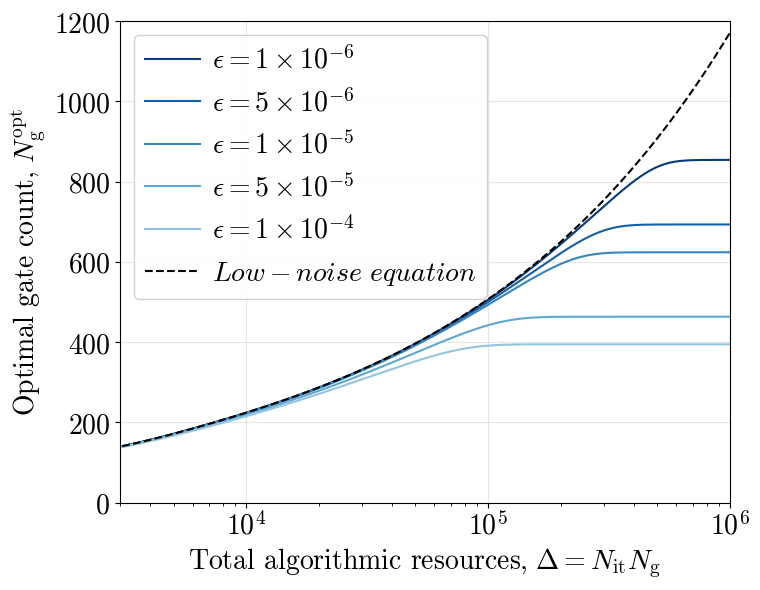


Figure saved as 'optimal_ng_delta_corrected.png'


In [8]:
# Color scheme: dark = low error, light = high error
colors = plt.cm.Blues(np.linspace(0.95, 0.4, len(eps_list)))
plt.rcParams["mathtext.fontset"] = "cm"

fig, ax = plt.subplots(figsize=(7.7, 6))

# Plot exact solutions for each epsilon
for color, eps in zip(colors, eps_list):
    Ng_eps = solutions[eps]
    mask = np.isfinite(Ng_eps)
    coef, exp = "{:.0e}".format(eps).split("e")
    label = rf"$\epsilon = {coef} \times 10^{{{int(exp)}}}$"
    ax.plot(D_sweep[mask], Ng_eps[mask], color=color, linewidth=1.5, label=label)

# Plot low-noise balance — enforce monotonicity to remove numerical artifacts
Ng_bal_clean = Ng_balance.copy()
for i in range(1, len(Ng_bal_clean)):
    if np.isfinite(Ng_bal_clean[i]) and np.isfinite(Ng_bal_clean[i-1]):
        if Ng_bal_clean[i] < Ng_bal_clean[i-1]:
            Ng_bal_clean[i] = np.nan
mask_b = np.isfinite(Ng_bal_clean)
ax.plot(D_sweep[mask_b], Ng_bal_clean[mask_b],
        color="black", linestyle="--", linewidth=1.5,
        label=r"$Low-noise~equation$")

# Plot per-curve crossover markers (plus markers)
for color, eps in zip(colors, eps_list):
    D_cross, Ng_cross = crossover_points[eps]
    if D_cross is not None:
        ax.plot(D_cross, Ng_cross, color=color, linestyle='None',
                zorder=5)

# Single black + for legend
#ax.plot([], [], marker='+', markersize=10, color='black', markeredgewidth=2.0,
#        linestyle='None', label=r"$\Delta_{\mathrm{cross}}(\epsilon)$")

# Format axes
ax.set_xscale("log")
ax.set_xlim(3e3, D_sweep[-1])
ax.set_ylim(0, 1200)

ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=5))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'$10^{{{int(np.log10(x))}}}$'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: rf'${y:g}$'))

ax.set_xlabel(r"$\text{Total algorithmic resources,}~\Delta = N_\text{it}N_\text{g}$", fontsize=20)
ax.set_ylabel(r"$\text{Optimal gate count,}~N_\text{g}^\text{opt}$", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.grid(alpha=0.3, which='major')

ax.legend(loc='upper left', fontsize=20, ncol=1, framealpha=0.9, columnspacing=0.8, handletextpad=0.4)

plt.tight_layout()
plt.savefig("optimal_ng_delta_corrected.png", bbox_inches='tight', dpi=300)
plt.show()

print(f"\nFigure saved as 'optimal_ng_delta_corrected.png'")

## 8) Detailed Crossover Analysis

Verify the transition from low-noise to large-$\Delta$ regime.

In [9]:
print("=" * 70)
print("CROSSOVER ANALYSIS")
print("=" * 70)

# Test at points below and above crossover
test_deltas = [1e3, 1e4, 3e4, 1e5, 3e5, 1e6]
eps_test = 1e-5

print(f"\nUsing ε = {eps_test:.0e}")
print(f"Crossover Δ ≈ {DELTA_CROSSOVER:.2e}\n")

print(f"{'Δ':<12} {'Ng_exact':<12} {'Ng_balance':<12} {'Ng_sat':<12} {'Regime':<20} {'Conv. err':<12} {'Noise bias':<12}")
print("-" * 100)

p_test = dict(params)
p_test["epsilon"] = eps_test
Ng_sat = large_delta_saturation(eps_test, params)

for Delta in test_deltas:
    Ng_exact = solve_ng_for_delta(Delta, p_test)
    Ng_bal = solve_low_noise_balance(Delta, params)
    
    if np.isfinite(Ng_exact):
        validity = check_validity_conditions(Ng_exact, Delta, eps_test, params)
        conv_err = validity['convergence_error']
        noise_bias = validity['noise_bias']
        
        if Delta < DELTA_CROSSOVER:
            regime = "Low-noise"
        else:
            regime = "Large-Δ (saturating)"
        
        print(f"{Delta:<12.0e} {Ng_exact:<12.1f} {Ng_bal:<12.1f} {Ng_sat:<12.1f} {regime:<20} {conv_err:<12.2e} {noise_bias:<12.2e}")
    else:
        print(f"{Delta:<12.0e} {'N/A':<12} {Ng_bal:<12.1f} {Ng_sat:<12.1f}")

print("\n" + "=" * 70)
print("KEY OBSERVATIONS:")
print("=" * 70)
print("1. For Δ << Δ_cross: Ng_exact ≈ Ng_balance (noise-independent)")
print("2. For Δ >> Δ_cross: Ng_exact → Ng_sat (ε-dependent ceiling)")
print("3. Crossover occurs when convergence error ≈ noise bias")

CROSSOVER ANALYSIS

Using ε = 1e-05


NameError: name 'DELTA_CROSSOVER' is not defined

## 9) Verify Curve Spacing: ~230 gates per decade

In [ ]:
print("=" * 60)
print("CURVE SPACING AT LARGE Δ")
print("=" * 60)

print(f"\nTheoretical prediction: Δ(Ng) = ln(10)/κ = {np.log(10)/params['kappa']:.1f} gates per decade")

# Measure actual spacing from saturation ceilings
print("\nFrom saturation formula:")
eps_pairs = [(1e-6, 1e-5), (1e-5, 1e-4), (5e-6, 5e-5)]
for eps1, eps2 in eps_pairs:
    Ng1 = large_delta_saturation(eps1, params)
    Ng2 = large_delta_saturation(eps2, params)
    spacing = Ng1 - Ng2
    decades = np.log10(eps2/eps1)
    print(f"  ε: {eps1:.0e} → {eps2:.0e} ({decades:.0f} decade): ΔNg = {spacing:.0f} gates")

# Measure from numerical solutions at large Delta
print("\nFrom numerical solutions at Δ = 1e6:")
Delta_large = 1e6
for eps1, eps2 in eps_pairs:
    p1 = dict(params); p1["epsilon"] = eps1
    p2 = dict(params); p2["epsilon"] = eps2
    Ng1 = solve_ng_for_delta(Delta_large, p1)
    Ng2 = solve_ng_for_delta(Delta_large, p2)
    if np.isfinite(Ng1) and np.isfinite(Ng2):
        spacing = Ng1 - Ng2
        decades = np.log10(eps2/eps1)
        print(f"  ε: {eps1:.0e} → {eps2:.0e} ({decades:.0f} decade): ΔNg = {spacing:.0f} gates")

## 10) Summary Table

In [ ]:
print("=" * 80)
print("SUMMARY OF REGIMES")
print("=" * 80)
print()
print(f"{'Regime':<25} {'Budget':<20} {'Balance':<30} {'ε-dependence'}")
print("-" * 80)
print(f"{'Low-noise (finite Δ)':<25} {'Δ ≲ Δ_cross':<20} {'Convergence vs. ansatz':<30} {'Approximately independent'}")
print(f"{'Large-Δ (low noise)':<25} {'Δ ≫ Δ_cross':<20} {'Ansatz vs. noise bias':<30} {'Logarithmic: ~ln(1/ε)/κ'}")
print(f"{'Large-Δ (high noise)':<25} {'Δ ≫ Δ_cross':<20} {'Noise dominates':<30} {'Constant or non-viable'}")
print("-" * 80)
print()
print(f"Crossover Delta: Δ_cross ≈ {DELTA_CROSSOVER:.2e}")
print(f"Curve spacing at large Δ: ~{np.log(10)/params['kappa']:.0f} gates per decade of noise reduction")
print(f"Critical noise (algorithm fails): ε_crit = βκ/|E_gs| ≈ {params['beta']*params['kappa']/abs(params['E_gs']):.1e}")